# Week 1 — Task 1: Prove why we visualize

**Dataset:** `data/datasaurus.csv` — 13 datasets, 142 points each, columns `dataset`, `x`, `y`.

**Question to answer:** we saw this effect with Anscombe's 4 datasets. Does having 13 datasets, and 142
points each instead of 11, make the summary statistics any more trustworthy?

> Run `python3 download_assignment_data.py` first, and run this notebook from the `assignments/` folder.

## 0. Setup

Same house style as the lecture notebook, so every chart looks like it came from the same place.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# ---- House palette (same as the lecture) ---------------------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
GREEN, VIOLET, RED = "#008300", "#4a3aa7", "#e34948"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]

# Ink + surface colours. Text is NEVER the colour of the data.
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

# ---- House style ---------------------------------------------------
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_SOFT,
        "axes.titlecolor": INK,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 14,
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "lines.linewidth": 2,
        "font.size": 11,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
    }
)


def save(fig, name):
    # Save every chart to charts/ so it can be dropped into slides.
    fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE)


def footnote(ax, text, y=-0.2):
    # One-line note under a chart: exclusions, sample sizes, caveats.
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)


print("Ready. pandas", pd.__version__)

Ready. pandas 3.0.2


## 1. Load and check the data

Before computing anything: how big is it, and is anything missing?

In [2]:
d = pd.read_csv(DATA / "datasaurus.csv")
print("Rows:", d.shape[0], " Columns:", list(d.columns))
print("Missing values:", int(d.isna().sum().sum()))
print("Datasets:", d["dataset"].nunique())
print("Points per dataset:", sorted(d.groupby("dataset").size().unique()))
d.head()

Rows: 1846  Columns: ['dataset', 'x', 'y']
Missing values: 0
Datasets: 13
Points per dataset: [np.int64(142)]


,dataset,x,y
0,dino,55.3846,97.1795
1,dino,51.5385,96.0256
2,dino,46.1538,94.4872
3,dino,42.8205,91.4103
4,dino,40.7692,88.3333


Nothing missing, 13 datasets, exactly 142 points in each. No cleaning is needed, so nothing is excluded
from any chart below.

## 2. Step 1 — the summary statistics table

Mean of `x` and `y`, standard deviation of both, and the correlation between them, for each of the 13
datasets.

In [3]:
summary = (
    d.groupby("dataset")
    .agg(
        n=("x", "size"),
        mean_x=("x", "mean"),
        mean_y=("y", "mean"),
        std_x=("x", "std"),
        std_y=("y", "std"),
    )
    .round(2)
)
summary["corr_xy"] = (
    d.groupby("dataset")
    .apply(lambda g: g["x"].corr(g["y"]), include_groups=False)
    .round(3)
)
summary

,n,mean_x,mean_y,std_x,std_y,corr_xy
dataset,,,,,,
away,142,54.27,47.83,16.77,26.94,-0.064
bullseye,142,54.27,47.83,16.77,26.94,-0.069
circle,142,54.27,47.84,16.76,26.93,-0.068
dino,142,54.26,47.83,16.77,26.94,-0.064
dots,142,54.26,47.84,16.77,26.93,-0.060
h_lines,142,54.26,47.83,16.77,26.94,-0.062
high_lines,142,54.27,47.84,16.77,26.94,-0.069
slant_down,142,54.27,47.84,16.77,26.94,-0.069
slant_up,142,54.27,47.83,16.77,26.94,-0.069


In [4]:
# How different are the 13 rows, really? Spread (max - min) of each statistic across the datasets.
spread = (summary.max() - summary.min()).rename("max - min across 13 datasets")
spread.to_frame().T.round(3)

,n,mean_x,mean_y,std_x,std_y,corr_xy
max - min across 13 datasets,0.0,0.01,0.01,0.01,0.01,0.009


## 3. Step 2 — what would I conclude if the table were all I had?

Every dataset has a mean of about **(54.3, 47.8)**, a standard deviation of about **(16.8, 26.9)** and a
correlation of about **−0.06**. The largest difference between any two datasets is 0.01 on the means,
0.01 on the standard deviations and 0.01 on the correlation (see the spread row above).

If the table were all I had, I would conclude that these are **thirteen copies of the same thing**: a
cloud of points centred near (54, 48), with a bit more spread up-and-down than left-to-right, and
essentially **no relationship** between `x` and `y` (a correlation of −0.06 is close to zero). I would
probably imagine a shapeless blob.

## 4. Step 3 — plot all 13 as a grid of scatter plots

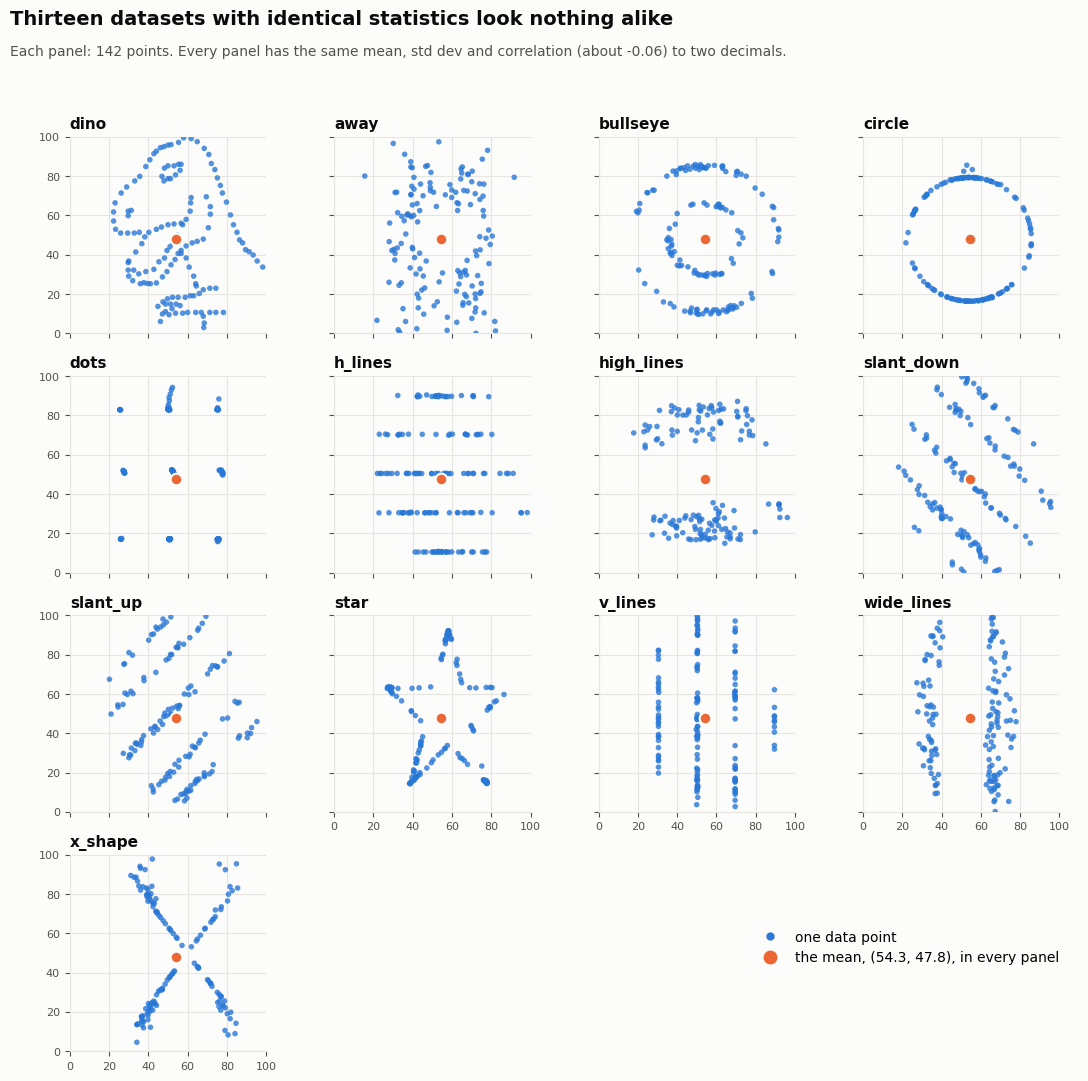

In [5]:
order = ["dino"] + [name for name in summary.index if name != "dino"]
mx, my = d["x"].mean(), d["y"].mean()

fig, axes = plt.subplots(4, 4, figsize=(11, 11), sharex=True, sharey=True)
flat = axes.flatten()

for ax, name in zip(flat, order):
    g = d[d["dataset"] == name]
    ax.scatter(g["x"], g["y"], s=16, color=BLUE, alpha=0.8, edgecolor="none", zorder=3)
    # The one thing that IS identical in every panel: the mean.
    ax.scatter([mx], [my], s=70, color=ORANGE, edgecolor=SURFACE, linewidth=1.5, zorder=4)
    ax.set_title(name, fontsize=11, loc="left", pad=6)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.tick_params(labelsize=8)
    ax.set_box_aspect(1)  # square panels: x and y are on the same 0-100 scale

# Panels 10-13 sit above an empty cell, so give them their own x tick labels.
for ax in flat[9:13]:
    ax.tick_params(labelbottom=True)

# The three spare cells stay empty; the key goes in the space they leave.
for ax in flat[13:]:
    ax.axis("off")
fig.suptitle(
    "Thirteen datasets with identical statistics look nothing alike",
    x=0.005, ha="left", fontsize=14, fontweight="bold", color=INK,
)
fig.text(
    0.005, 0.938,
    "Each panel: 142 points. Every panel has the same mean, std dev and correlation (about -0.06) to two decimals.",
    ha="left", fontsize=10, color=INK_SOFT,
)
fig.tight_layout(rect=[0, 0, 1, 0.93])

from matplotlib.lines import Line2D
key = [
    Line2D([], [], marker="o", ls="", color=BLUE, markersize=5, label="one data point"),
    Line2D([], [], marker="o", ls="", color=ORANGE, markersize=9,
           label=f"the mean, ({mx:.1f}, {my:.1f}), in every panel"),
]
fig.legend(handles=key, loc="lower right", bbox_to_anchor=(0.97, 0.10), fontsize=10)

save(fig, "t1_datasaurus_grid")
plt.show()

**Why a grid of scatter plots (small multiples)?** The question is *"what shape is each dataset?"*, and
the data is two numeric variables per point. Two numeric variables means a **scatter plot**: it is the
only chart that shows the position of every observation on both variables at once (a line or bar chart
would already have averaged the shape away, which is the very thing we are trying to expose). There are
13 datasets, so I use **small multiples**: one panel each, on **identical axes (0–100 for both)**, so the
eye can compare shapes directly. Overlaying all 13 in one plot would give a meaningless smear. The colour
means something here: orange is the shared mean, blue is the data.

## 5. Step 4 — what I actually found

The table said "one shapeless blob with no relationship". The picture says otherwise: the 13 datasets are
a **dinosaur**, a **star**, a **circle**, a **bullseye**, an **X**, a set of **dots** in a 3×3 grid, and
several sets of **horizontal, vertical, slanted and wide lines**. They are wildly different, yet every
one produces the same five numbers (to two decimal places).

Two consequences follow:

- The correlation of −0.06 is a true statement about *all* of them, and a useless one. Correlation only
  measures **straight-line** association. A circle, a star and a dinosaur have structure, but not linear
  structure, so the coefficient sees nothing.
- The 13 sets were **constructed on purpose** to match each other (Matejka & Fitzmaurice, 2017, by
  gradually nudging the points of the dinosaur until it became each target shape while the statistics
  stayed fixed). So this is a demonstration, not a natural discovery. But it proves the point: because
  it is *possible* to build such data, identical summary statistics can never prove that two datasets are
  alike.

## 6. The question: do 13 datasets of 142 points make the statistics more trustworthy?

**No. More data makes the numbers more *precise*, not more *valid*.**

A bigger sample shrinks the uncertainty around a statistic. The next cell puts a number on that.

In [6]:
def corr_ci(r, n, z=1.96):
    # Approximate 95% confidence interval for a correlation (Fisher z-transform).
    zr, se = np.arctanh(r), 1 / np.sqrt(n - 3)
    return np.tanh(zr - z * se), np.tanh(zr + z * se)

rows = []
for label, r, n in [
    ("Anscombe, any of the 4 (r = 0.816, n = 11)", 0.816, 11),
    ("dino's r, if we only had 11 points", summary.loc["dino", "corr_xy"], 11),
    ("dino's r, with all 142 points", summary.loc["dino", "corr_xy"], 142),
]:
    lo, hi = corr_ci(r, n)
    rows.append({"dataset": label, "r": r, "95% CI low": round(lo, 2), "95% CI high": round(hi, 2),
                 "CI width": round(hi - lo, 2)})
pd.DataFrame(rows).set_index("dataset")

,r,95% CI low,95% CI high,CI width
dataset,,,,
"Anscombe, any of the 4 (r = 0.816, n = 11)",0.816,0.42,0.95,0.53
"dino's r, if we only had 11 points",-0.064,-0.64,0.56,1.20
"dino's r, with all 142 points",-0.064,-0.23,0.10,0.33


Compare the last two rows: the *same* correlation (−0.064) is pinned down to a window about **1.2** wide
with 11 points, but only about **0.33** wide with 142. (The first row is not comparable, because intervals
are naturally narrower when r is large.) So yes, the **estimate is much tighter**: with 142 points we are
fairly sure the linear correlation of the dino data is somewhere near zero.

But look at what that buys us. We are now very sure about the value of a number that **still describes
nothing about the shape**. The interval says "the linear correlation is close to zero"; it cannot say
"the points form a star". Sample size controls **random error** (how much the statistic would wobble
if you re-drew the sample). It does nothing about **model error** (whether a mean, a standard deviation
and a straight-line correlation are the right questions to ask). Anscombe's problem and the Datasaurus
problem are the same problem, and 13 × 142 points does not fix it:

1. **Summaries compress.** Five numbers cannot hold 142 points' worth of shape, whatever n is.
2. **The statistic must fit the data.** Pearson correlation assumes a linear relationship; when the
   relationship is a circle or a curve, a precise answer to the wrong question is still wrong.
3. **More datasets show the effect is general, not that it is rarer.** Thirteen very different shapes
   sharing the same statistics is *stronger* evidence that statistics alone are not enough.

> **Rule from the lecture, confirmed:** plot first, then compute. A chart is how you check what your
> summary statistics threw away.